In [1]:
import polars as pl
import seaborn as sns
import matplotlib as mat
import matplotlib.pyplot as plt

In [2]:
df = pl.read_csv("bank.csv", separator=";")

In [3]:
df.head()

age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
i64,str,str,str,str,i64,str,str,str,i64,str,i64,i64,i64,i64,str,str
30,"""unemployed""","""married""","""primary""","""no""",1787,"""no""","""no""","""cellular""",19,"""oct""",79,1,-1,0,"""unknown""","""no"""
33,"""services""","""married""","""secondary""","""no""",4789,"""yes""","""yes""","""cellular""",11,"""may""",220,1,339,4,"""failure""","""no"""
35,"""management""","""single""","""tertiary""","""no""",1350,"""yes""","""no""","""cellular""",16,"""apr""",185,1,330,1,"""failure""","""no"""
30,"""management""","""married""","""tertiary""","""no""",1476,"""yes""","""yes""","""unknown""",3,"""jun""",199,4,-1,0,"""unknown""","""no"""
59,"""blue-collar""","""married""","""secondary""","""no""",0,"""yes""","""no""","""unknown""",5,"""may""",226,1,-1,0,"""unknown""","""no"""


In [4]:
df.shape

(4521, 17)

In [5]:
# Verificar quantidade de campos nulos
df.null_count()

age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
#Verificar quantidade de valores em cada coluna
for col in df.columns:
    print(f"Contagem de valores em {col}:")
    print(df[col].value_counts())


Contagem de valores em age:
shape: (67, 2)
┌─────┬───────┐
│ age ┆ count │
│ --- ┆ ---   │
│ i64 ┆ u32   │
╞═════╪═══════╡
│ 41  ┆ 135   │
│ 76  ┆ 2     │
│ 73  ┆ 6     │
│ 46  ┆ 119   │
│ 65  ┆ 6     │
│ …   ┆ …     │
│ 42  ┆ 141   │
│ 55  ┆ 90    │
│ 54  ┆ 71    │
│ 39  ┆ 130   │
│ 59  ┆ 71    │
└─────┴───────┘
Contagem de valores em job:
shape: (12, 2)
┌──────────────┬───────┐
│ job          ┆ count │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ housemaid    ┆ 112   │
│ unemployed   ┆ 128   │
│ management   ┆ 969   │
│ admin.       ┆ 478   │
│ unknown      ┆ 38    │
│ …            ┆ …     │
│ retired      ┆ 230   │
│ student      ┆ 84    │
│ entrepreneur ┆ 168   │
│ blue-collar  ┆ 946   │
│ services     ┆ 417   │
└──────────────┴───────┘
Contagem de valores em marital:
shape: (3, 2)
┌──────────┬───────┐
│ marital  ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ married  ┆ 2797  │
│ single   ┆ 1196  │
│ divorced ┆ 528   │
└──

In [7]:
#Coluna com mais de 70% dos valores desconhecidos. Será removida
df.drop('poutcome')

age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,y
i64,str,str,str,str,i64,str,str,str,i64,str,i64,i64,i64,i64,str
30,"""unemployed""","""married""","""primary""","""no""",1787,"""no""","""no""","""cellular""",19,"""oct""",79,1,-1,0,"""no"""
33,"""services""","""married""","""secondary""","""no""",4789,"""yes""","""yes""","""cellular""",11,"""may""",220,1,339,4,"""no"""
35,"""management""","""single""","""tertiary""","""no""",1350,"""yes""","""no""","""cellular""",16,"""apr""",185,1,330,1,"""no"""
30,"""management""","""married""","""tertiary""","""no""",1476,"""yes""","""yes""","""unknown""",3,"""jun""",199,4,-1,0,"""no"""
59,"""blue-collar""","""married""","""secondary""","""no""",0,"""yes""","""no""","""unknown""",5,"""may""",226,1,-1,0,"""no"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
33,"""services""","""married""","""secondary""","""no""",-333,"""yes""","""no""","""cellular""",30,"""jul""",329,5,-1,0,"""no"""
57,"""self-employed""","""married""","""tertiary""","""yes""",-3313,"""yes""","""yes""","""unknown""",9,"""may""",153,1,-1,0,"""no"""
57,"""technician""","""married""","""secondary""","""no""",295,"""no""","""no""","""cellular""",19,"""aug""",151,11,-1,0,"""no"""


In [8]:
#Separando os grupos que aceitaram contratar o produto e os que não aceitaram
df_yes = df.filter(pl.col("y") == "yes")
df_no = df.filter(pl.col("y") == "no")

C:\Users\vilia\AppData\Local\Temp\ipykernel_11684\1667950712.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="y", y="duration", data=df, notch=True, palette="deep")


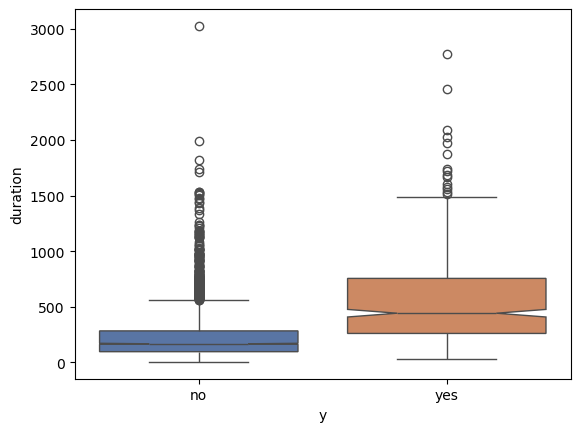

In [32]:
#Comparando a duração de tempo de contato entre quem contratou ou não
sns.boxplot(x="y", y="duration", data=df, notch=True, palette="deep")
plt.show()


C:\Users\vilia\AppData\Local\Temp\ipykernel_11684\1960889687.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="y", y="pdays", data=df, palette="bright")


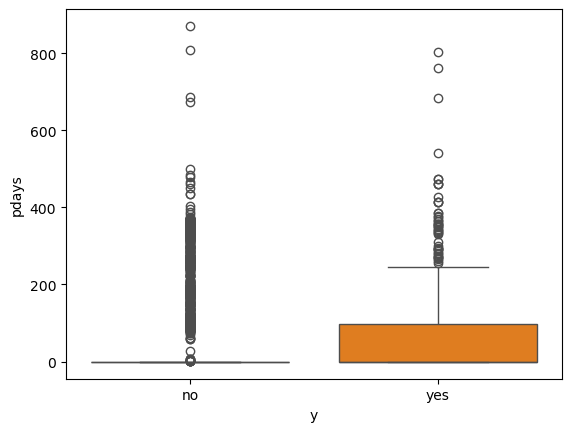

In [33]:
#Tempo em dias do último contato. Ninguém que aceitou o produto foi abordado pela primeira vez
sns.boxplot(x="y", y="pdays", data=df, palette="bright")
plt.show()

C:\Users\vilia\AppData\Local\Temp\ipykernel_11684\3483468948.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="y", y="age", notch=True, palette="pastel")


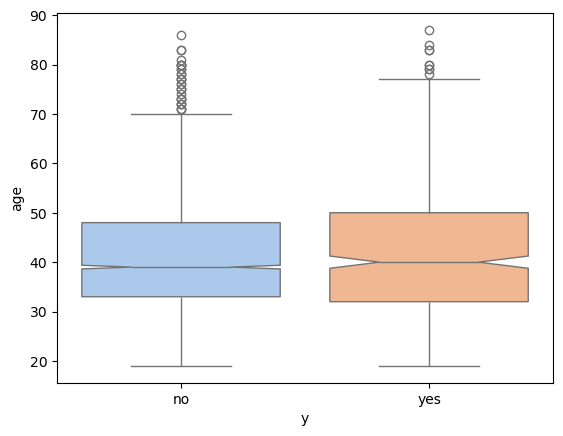

In [34]:
# Comparando idade dos clientes que aplicaram ou não no investimento oferecido.
sns.boxplot(data=df, x="y", y="age", notch=True, palette="pastel")
plt.show()

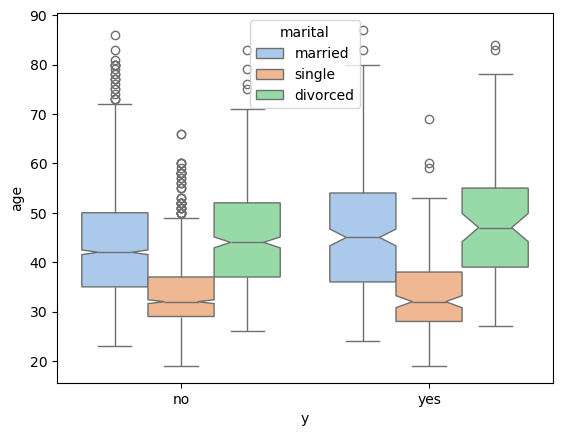

In [36]:
#Comparando idade, estado civil para verificar se há diferença entre quem contratou ou não
sns.boxplot(data=df, x="y", y="age", hue="marital", notch=True, palette="pastel")
plt.show()

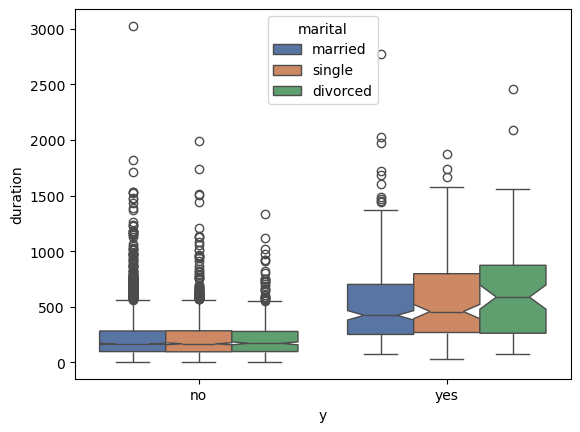

In [39]:
#Comparando duração do atendimento, estado civil para verificar se há diferença entre quem contratou ou não
sns.boxplot(data=df, x="y", y="duration", hue="marital", notch=True, palette="deep")
plt.show()

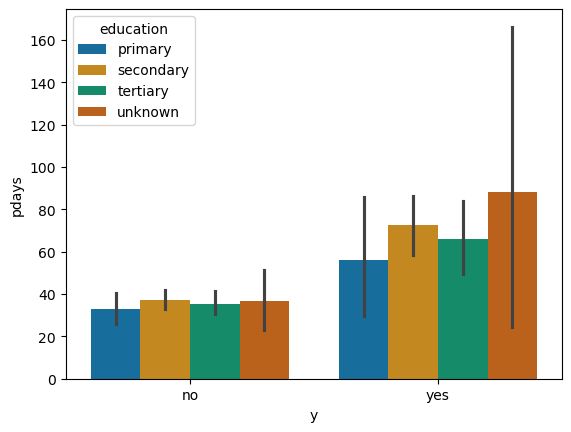

In [42]:
#Comparando tempo do último contato, escolaridade para verificar se há diferença entre quem contratou ou não
sns.barplot(data=df, x="y", y="pdays", hue="education", palette="colorblind")
plt.show()